# Text-to-SQL RL with Verifiable Rewards

This notebook is an interactive tutorial covering the Reinforcement Learning (RL) half of the Text-to-SQL recipe. 

In Group Relative Policy Optimization (GRPO), the model generates multiple SQL candidates per prompt. We execute each query in SQLite, score the correctness of the returned rows, and use the group's average performance as our baseline to compute advantages. 

In [ ]:
from __future__ import annotations

import asyncio
import random
import statistics
from typing import Any

import tinker
import pandas as pd
from tinker import types
from transformers import AutoTokenizer

from tinker_cookbook.utils import ml_log
from utils.helpers import require_server


/usr/local/google/home/shuby/RL/ttsql-rl-notebook/examples/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Prerequisite: Start the Open-RL Server

Before running this notebook, you must start the underlying Open-RL API server. 

Depending on your deployment target, please follow one of these guides to start the server:

*   **For Local VM Deployment (Recommended for learning):** Follow the [Text-to-SQL RL Recipe Guide](README.md#deploying-openrl) to provision a GPU VM and start the vLLM sampler and Open-RL server.
*   **For Kubernetes Deployment (GKE):** Follow the [Text-to-SQL GKE Guide](../../../k8s/deploy/text-to-sql-gke/README.md) to deploy the gateway, vLLM worker, and trainer worker on GKE.

Once your server is running and accessible (typically at `http://127.0.0.1:9003` via port-forwarding or local run), you can proceed with the cells below.

## Configuration & Boilerplate

We define the connection and training parameters here. These defaults mirror the Gemma 4 E2B RL preset in `texttosql_sft_grpo.py`.

In [ ]:
BASE_URL = "http://127.0.0.1:9003"
BASE_MODEL = "google/gemma-4-e2b"

config = {
    "base_url": BASE_URL,
    "model": BASE_MODEL,
    "rank": 32,
    "seed": 42,
    "dataset_limit": 12_500,
    "rl_train_limit": 5_000,
    "eval_limit": 100,
    "eval_max_tokens": 64,
    "steps": 80,
    "eval_every": 10,
    "prompts_per_step": 8,
    "samples_per_prompt": 8,
    "max_tokens": 64,
    "temperature": 0.8,
    "loss_fn": "ppo",
    "learning_rate": 5e-6,
    "grad_clip_norm": 0.3,
    "clip_range": 0.2,
    "kl_coeff": 0.1,
}

service_client = tinker.ServiceClient(api_key="tml-dummy-key", base_url=config["base_url"])

server_model = await require_server(service_client, config["base_url"], expected_model=config["model"])
print(f"Successfully connected to Open-RL server at {config['base_url']}")
print(f"Active Server Model: {server_model}")

Successfully connected to Open-RL server at http://127.0.0.1:9003
Active Server Model: google/gemma-4-e2b


---
## Step 1: Load the Dataset

We load executable Text-to-SQL rows.

In [3]:
from utils.rewards import load_dataset_splits

train_rows, eval_rows = load_dataset_splits(
    dataset_limit=config["dataset_limit"],
    train_limit=config["rl_train_limit"],
    eval_limit=config["eval_limit"],
    seed=config["seed"],
)

# Display one example row
example_row = train_rows[0]
print("Example Row from Dataset:")
print(f"Question: {example_row.get('question')}")
print(f"Target SQL: {example_row.get('target')}")
print(f"Schema:\n{example_row.get('context')}")

Example Row from Dataset:
Question: List the top 5 digital assets by the total number of transactions.
Target SQL: SELECT asset, COUNT(*) AS total_tx FROM transactions GROUP BY asset ORDER BY total_tx DESC LIMIT 5;
Schema:
CREATE TABLE transactions (asset TEXT, tx_date DATE); INSERT INTO transactions (asset, tx_date) VALUES ('Securitize', '2021-01-01'), ('Securitize', '2021-01-02'), ('Polymath', '2021-01-01'), ('Polymath', '2021-01-02'), ('Polymath', '2021-01-03');


---
## Step 2: Make a Prompt and Tokenize

Every example receives a database schema context and a human question. We combine these into a structured prompt, and then tokenize the dataset for training.

In [ ]:
PROMPT_TEMPLATE = """Return only one SQLite query.

Schema:
{schema}

Question:
{question}

SQL:
"""

def make_prompt(schema: str, question: str) -> str:
    return PROMPT_TEMPLATE.format(schema=schema, question=question)

sample_prompt = make_prompt(example_row["context"], example_row["question"])
print("Actual Prompt Example:")
print(sample_prompt)

tokenizer = AutoTokenizer.from_pretrained(config["model"])

def prepare_examples(rows):
    examples = []
    for row in rows:
        prompt_text = make_prompt(row["context"], row["question"])
        prompt_tokens = tokenizer.encode(prompt_text, add_special_tokens=False)
        examples.append({
            "schema": row["context"],
            "question": row["question"],
            "target_sql": row["target"],
            "target_rows": row["target_rows"],
            "prompt_text": prompt_text,
            "prompt_tokens": prompt_tokens,
        })
    return examples

train_examples = prepare_examples(train_rows)
eval_examples = prepare_examples(eval_rows)

print(f"Successfully tokenized RL datasets:")
print(f"- {len(train_examples)} RL train examples")
print(f"- {len(eval_examples)} eval examples")

Actual Prompt Example:
Return only one SQLite query.

Schema:
CREATE TABLE transactions (asset TEXT, tx_date DATE); INSERT INTO transactions (asset, tx_date) VALUES ('Securitize', '2021-01-01'), ('Securitize', '2021-01-02'), ('Polymath', '2021-01-01'), ('Polymath', '2021-01-02'), ('Polymath', '2021-01-03');

Question:
List the top 5 digital assets by the total number of transactions.

SQL:

Successfully tokenized RL datasets:
- 5000 RL train examples
- 100 eval examples


---
## Step 3: Score SQL and Convert Rewards to Advantages

Execution is the verifiable part of the system: each generated query runs against an in-memory SQLite database and is scored against the target rows. GRPO then standardizes rewards within each sampled group to produce advantages without a separate critic model.

In [ ]:
from utils.rewards import aggregate_eval_scores, normalize_sql, score_eval_prediction


def score_sql(predicted_sql: str, example: dict[str, Any]) -> dict[str, Any]:
    return score_eval_prediction(predicted_sql, {
            "question": example["question"],
            "context": example["schema"],
            "target": example["target_sql"],
            "target_rows": example["target_rows"],
        }
    )


def group_advantages(rewards: list[float]) -> list[float]:
    if len(rewards) < 2: return [0.0] * len(rewards)

    std = statistics.pstdev(rewards)

    if std < 1e-8: return [0.0] * len(rewards)

    mean = statistics.fmean(rewards)
    return [(reward - mean) / std for reward in rewards]


example_score = score_sql(train_examples[0]["target_sql"], train_examples[0])
print(f"Reward: {example_score['reward']:.2f}")
print(f"Compiles: {bool(example_score['compile'])}")
print(f"Execution match: {bool(example_score['execution_match'])}")
print(f"Normalized SQL: {normalize_sql(example_score['predicted_sql'])}")


Reward: 3.05
Compiles: True
Execution match: True
Normalized SQL: select asset,count(*) as total_tx from transactions group by asset order by total_tx desc limit 5


---
## Step 4: Build the PPO Datum

In [ ]:
def make_datum(prompt_tokens: list[int], completion_tokens: list[int], completion_logprobs: list[float], advantage: float) -> types.Datum:
    tokens = prompt_tokens + completion_tokens
    prompt_padding = [0.0] * (len(prompt_tokens) - 1)
    completion_weights = [1.0] * len(completion_tokens)

    return types.Datum(
        model_input=types.ModelInput.from_ints(tokens=tokens[:-1]),
        loss_fn_inputs={
            "target_tokens": tokens[1:],
            "weights": prompt_padding + completion_weights,
            "logprobs": prompt_padding + completion_logprobs,
            "advantages": prompt_padding + [advantage] * len(completion_tokens),
        },
    )


example_datum = make_datum(
    prompt_tokens=[101, 102, 103],
    completion_tokens=[201, 202],
    completion_logprobs=[-0.3, -0.4],
    advantage=1.25,
)
print(f"Model input tokens: {example_datum.model_input.chunks[0].tokens}")
print(f"Target tokens: {example_datum.loss_fn_inputs['target_tokens'].data}")
print(f"Weights: {example_datum.loss_fn_inputs['weights'].data}")
print(f"Advantages: {example_datum.loss_fn_inputs['advantages'].data}")


Model input tokens: [101, 102, 103, 201]
Target tokens: [102, 103, 201, 202]
Weights: [0.0, 0.0, 1.0, 1.0]
Advantages: [0.0, 0.0, 1.25, 1.25]


---
## Step 5: Sample, Score, and Train One RL Update

This is the core RL step: save weights for sampling, request completions, score each SQL candidate, convert group rewards to advantages, and send trainable PPO datums back to Open-RL.

In [ ]:
async def grpo_step(trainer: Any, examples: list[dict[str, Any]], step: int) -> tuple[dict[str, float], str]:
    sampler = await trainer.save_weights_and_get_sampling_client_async(name=f"texttosql_notebook_rollout_s{step}")
    sampling_params = types.SamplingParams(max_tokens=config["max_tokens"], temperature=config["temperature"])

    futures = []
    for example in examples:
        prompt = types.ModelInput.from_ints(tokens=example["prompt_tokens"])
        future = sampler.sample_async(prompt=prompt, num_samples=config["samples_per_prompt"], sampling_params=sampling_params)
        futures.append(future)

    responses = await asyncio.gather(*futures)

    all_rollouts: list[dict[str, Any]] = []
    datums: list[types.Datum] = []
    skipped_zero_advantage = 0
    skipped_missing_logprobs = 0

    for example, response in zip(examples, responses):
        group = []
        for seq in response.sequences:
            predicted_sql = tokenizer.decode(seq.tokens, skip_special_tokens=True)
            group.append({
                **score_sql(predicted_sql, example),
                "prompt_tokens": example["prompt_tokens"],
                "completion_tokens": list(seq.tokens),
                "completion_logprobs": [float(v) for v in (seq.logprobs or [])],
            })

        rewards = [float(item["reward"]) for item in group]
        advantages = group_advantages(rewards)

        for rollout, advantage in zip(group, advantages):
            rollout = {**rollout, "advantage": advantage}
            all_rollouts.append(rollout)

            if abs(advantage) < 1e-8:
                skipped_zero_advantage += 1
                continue
            if len(rollout["completion_tokens"]) != len(rollout["completion_logprobs"]):
                skipped_missing_logprobs += 1
                continue

            datum = make_datum(rollout["prompt_tokens"], rollout["completion_tokens"], rollout["completion_logprobs"], advantage)
            datums.append(datum)

    fwdbwd_future = await trainer.forward_backward_async(
        datums,
        config["loss_fn"],
        loss_fn_config={"clip_range": config["clip_range"], "kl_coeff": config["kl_coeff"]},
    )

    adam_params = types.AdamParams(learning_rate=config["learning_rate"], grad_clip_norm=config["grad_clip_norm"])
    optim_future = await trainer.optim_step_async(adam_params)

    fwdbwd = await fwdbwd_future
    await optim_future

    best = max(all_rollouts, key=lambda item: (item["reward"], item["execution_match"], item.get("similarity", 0.0)))
    metric_fields = ("reward", "compile", "execution_match", "similarity")
    metrics = {name: statistics.fmean(float(item.get(name, 0.0)) for item in all_rollouts) for name in metric_fields}

    metrics.update({
        "loss": float(fwdbwd.metrics.get("loss:mean", 0.0)),
        "num_rollouts": float(len(all_rollouts)),
        "num_train_datums": float(len(datums)),
        "skipped_zero_advantage": float(skipped_zero_advantage),
        "skipped_missing_logprobs": float(skipped_missing_logprobs),
    })

    note = (
        f"Predicted: {normalize_sql(best['predicted_sql'])}\n"
        f"Reward: {best['reward']:.2f} | Advantage: {best['advantage']:.2f}\n"
        f"Train datums: {len(datums)} / sampled rollouts: {len(all_rollouts)}"
    )
    return metrics, note


---
## Step 6: Evaluate the Current Adapter

Use deterministic sampling on held-out examples so the notebook can show whether training changes execution accuracy, exact SQL match, and shaped similarity.

In [ ]:
async def eval_step(trainer: Any, examples: list[dict[str, Any]], step: int) -> dict[str, float]:
    sampler = await trainer.save_weights_and_get_sampling_client_async(name=f"texttosql_notebook_eval_s{step}")

    futures = []

    for idx, example in enumerate(examples):
        prompt = types.ModelInput.from_ints(tokens=example["prompt_tokens"])
        sampling_params = types.SamplingParams(
            max_tokens=config["eval_max_tokens"],
            seed=config["seed"] + idx,
            temperature=0.0,
        )
        future = sampler.sample_async(prompt=prompt, num_samples=1, sampling_params=sampling_params)
        futures.append(future)

    responses = await asyncio.gather(*futures)

    scores = []
    for example, response in zip(examples, responses):
        tokens = response.sequences[0].tokens if response.sequences else []
        predicted_sql = tokenizer.decode(tokens, skip_special_tokens=True)
        scores.append(score_sql(predicted_sql, example))

    return aggregate_eval_scores(scores)


---
## Step 7: Run the RL Loop

This loop uses the same Gemma 4 E2B RL recipe hyperparameters as `texttosql_sft_grpo.py`. It records a baseline eval snapshot before training, then evaluates every `config["eval_every"]` RL steps.

In [9]:
training_records = []
rollout_notes = []

ml_logger = ml_log.JsonLogger("artifacts/texttosql_grpo_notebook")
ml_logger.log_hparams(config)

rng = random.Random(config["seed"])
# Reuse the service_client initialized at the top
trainer = await service_client.create_lora_training_client_async(
    base_model=config["model"],
    rank=config["rank"],
    seed=config["seed"],
    train_mlp=True,
    train_attn=True,
    train_unembed=False,
)

baseline_eval = await eval_step(trainer, eval_examples, 0)
ml_logger.log_metrics({"phase": "rl_eval", **baseline_eval}, step=0)
training_records.append({"phase": "rl_eval", "step": 0, **baseline_eval})
print(
    f"eval 000: exec={baseline_eval['execution_match'] * 100:.1f}% "
    f"exact={baseline_eval['exact_match'] * 100:.1f}% "
    f"similarity={baseline_eval['similarity'] * 100:.1f}%"
)

for step in range(1, config["steps"] + 1):
    batch = rng.sample(train_examples, k=min(config["prompts_per_step"], len(train_examples)))
    metrics, note = await grpo_step(trainer, batch, step)

    ml_logger.log_metrics({"phase": "rl_train", **metrics}, step=step)
    training_records.append({"phase": "rl_train", "step": step, **metrics})
    rollout_notes.append(f"step {step}\n{note}")

    print(
        f"step {step:03d}: reward={metrics['reward']:.3f} "
        f"exec={metrics['execution_match'] * 100:.1f}% "
        f"compile={metrics['compile'] * 100:.1f}% "
        f"rollouts={metrics['num_rollouts']:.0f} "
        f"train_datums={metrics['num_train_datums']:.0f}"
    )

    if step % config["eval_every"] == 0 or step == config["steps"]:
        eval_metrics = await eval_step(trainer, eval_examples, step)
        ml_logger.log_metrics({"phase": "rl_eval", **eval_metrics}, step=step)
        training_records.append({"phase": "rl_eval", "step": step, **eval_metrics})
        print(
            f"eval {step:03d}: exec={eval_metrics['execution_match'] * 100:.1f}% "
            f"exact={eval_metrics['exact_match'] * 100:.1f}% "
            f"similarity={eval_metrics['similarity'] * 100:.1f}%"
        )

ml_logger.close()
metrics_df = pd.DataFrame(training_records)
metrics_df


eval 000: exec=5.0% exact=2.0% similarity=37.4%
step 001: reward=0.293 exec=9.4% compile=15.6% rollouts=64 train_datums=64
step 002: reward=0.176 exec=6.2% compile=7.8% rollouts=64 train_datums=64
step 003: reward=-0.028 exec=0.0% compile=4.7% rollouts=64 train_datums=64
step 004: reward=-0.064 exec=0.0% compile=3.1% rollouts=64 train_datums=64
step 005: reward=-0.043 exec=0.0% compile=3.1% rollouts=64 train_datums=64
step 006: reward=0.011 exec=3.1% compile=6.2% rollouts=64 train_datums=64
step 007: reward=0.156 exec=6.2% compile=10.9% rollouts=64 train_datums=64
step 008: reward=-0.088 exec=0.0% compile=1.6% rollouts=64 train_datums=64
step 009: reward=0.090 exec=4.7% compile=10.9% rollouts=64 train_datums=64
step 010: reward=-0.018 exec=1.6% compile=6.2% rollouts=64 train_datums=64
eval 010: exec=8.0% exact=2.0% similarity=38.2%
step 011: reward=0.274 exec=10.9% compile=12.5% rollouts=64 train_datums=64
step 012: reward=-0.021 exec=1.6% compile=1.6% rollouts=64 train_datums=64
step 

,phase,step,execution_match,exact_match,execution_match_not_exact,similarity,reward,compile,loss,num_rollouts,num_train_datums,skipped_zero_advantage,skipped_missing_logprobs
0,rl_eval,0,0.050000,0.02,0.03,0.374037,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,rl_train,1,0.093750,NaN,NaN,0.448428,0.293346,0.156250,0.000549,64.0,64.0,0.0,0.0
2,rl_train,2,0.062500,NaN,NaN,0.314042,0.176265,0.078125,-1.834946,64.0,64.0,0.0,0.0
3,rl_train,3,0.000000,NaN,NaN,0.254215,-0.027716,0.046875,-1.938669,64.0,64.0,0.0,0.0
4,rl_train,4,0.000000,NaN,NaN,0.257558,-0.063948,0.031250,1.250755,64.0,64.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,rl_train,77,0.343750,NaN,NaN,0.685315,1.304604,0.656250,0.081604,64.0,64.0,0.0,0.0
85,rl_train,78,0.093750,NaN,NaN,0.443949,0.437013,0.265625,0.343110,64.0,64.0,0.0,0.0
86,rl_train,79,0.140625,NaN,NaN,0.556934,0.542644,0.265625,0.262188,64.0,64.0,0.0,0.0
87,rl_train,80,0.031250,NaN,NaN,0.565705,0.477936,0.468750,0.196482,64.0,64.0,0.0,0.0


---
## Step 8: Graph the Results

Plot train-loop reward/loss separately from held-out eval metrics. The eval lines are the best signal for whether the adapter is improving beyond rollout reward shaping.

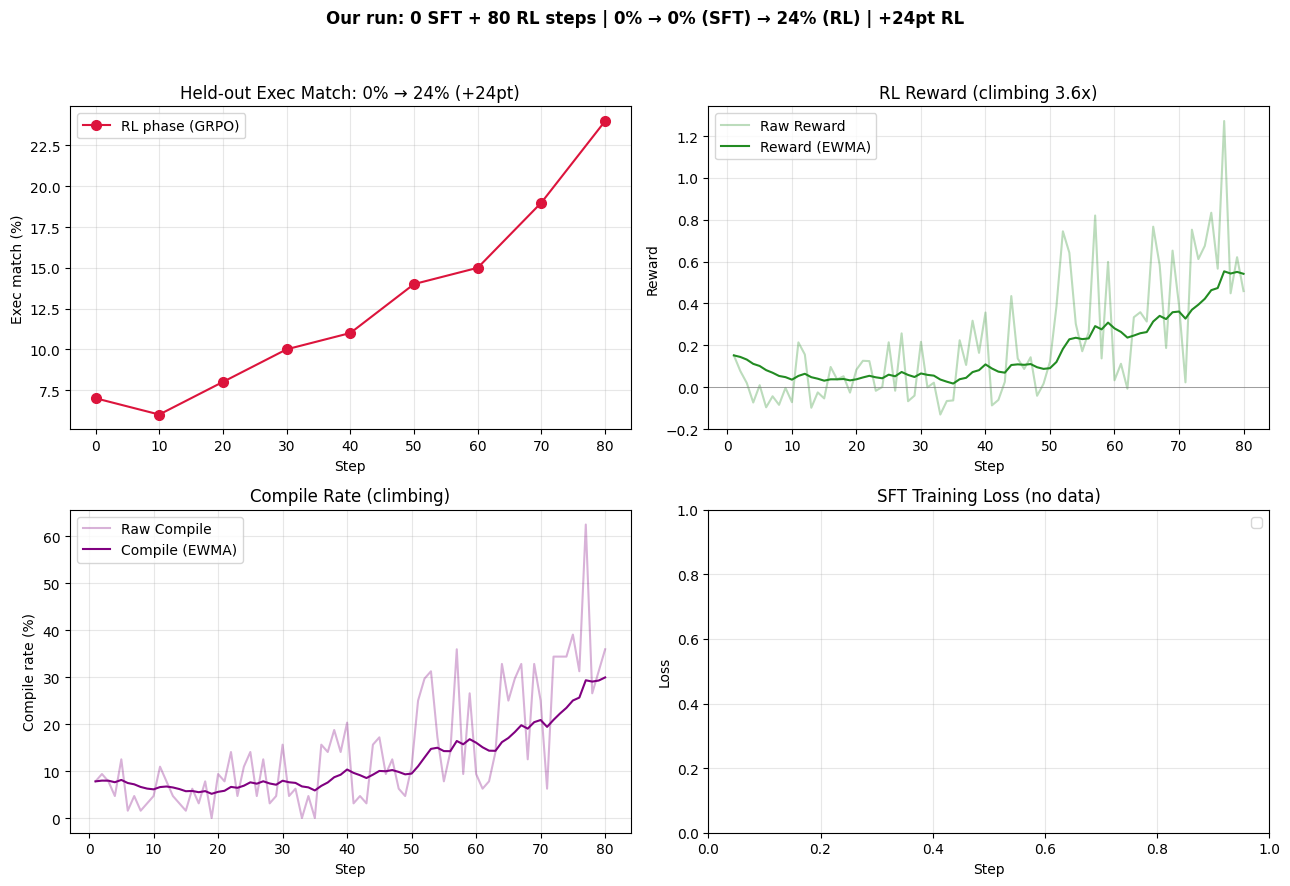

In [30]:
from utils.plot import parse_metrics_file, render_recipe_plots

metrics_path = "artifacts/texttosql_grpo_notebook/metrics.jsonl"
rows = parse_metrics_file(metrics_path)

if rows:
    fig = render_recipe_plots(rows)
    import matplotlib.pyplot as plt
    plt.show()
else:
    print(f"No metrics found yet at {metrics_path}. Please run the Step 8 loop first!")

---
## Connect Back to the Full Recipe

This notebook loop is optimized for interactive debugging. The complete production script (`texttosql_sft_grpo.py`) still contains additional features for longer runs:
- **Optional SFT warm start**: Helps unaligned models output valid SQL structure quickly.
- **Full recipe orchestration**: Saves named SFT/final adapter states and writes the complete metrics log for offline analysis.